In [2]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint, uniform
from sklearn.datasets import make_classification



#Load csv
train = pd.read_csv('/content/drive/MyDrive/AlfredTest/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')
sample_submission = pd.read_csv('/content/sample_data/sample_submission.csv')



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Show the head
print(train.head())
print(test.head())

      Ticker        Date      Open      High       Low     Close    Volume  \
0   ticker_1  1962-01-02  0.000000  0.265828  0.261788  0.261788   25600.0   
1  ticker_20  1962-01-02  0.000000  0.417455  0.412380  0.414917   84139.0   
2  ticker_19  1962-01-02  0.000000  0.101537  0.100789  0.100789  902400.0   
3  ticker_18  1962-01-02  0.000000  0.903030  0.881959  0.881959   51552.0   
4  ticker_17  1962-01-02  0.130512  0.131783  0.129241  0.130512  163200.0   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  
            ID        Date
0     ticker_1  2024-11-04
1    ticker_10  2024-11-04
2   ticker_100  2024-11-04
3  ticker_1000  2024-11-04
4  ticker_1001  2024-11-04


In [4]:
#Convert date to datetime type
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

#Ordenar por ticker y fecha
train = train.sort_values(['Ticker', 'Date']).reset_index(drop=True)

This part converts the Date column in both the train and test DataFrames into datetime format using pd.to_datetime
This ensures that the column can be used for time-based operations like sorting, filtering by year/month, or calculating time differences

In [5]:
#Create Target
# For each stock, the target is whether the Close price goes up or down after 30 days
train['Target'] = train.groupby('Ticker')['Close'].shift(-30) > train['Close']
train['Target'] = train['Target'].astype(int)

#We eliminate rows where we cannot calculate the target (last 30 days of each action)
train = train.dropna(subset=['Target'])

In this part of the code, I'm creating the target variable for my prediction model.
What I want to know is whether a stock's closing price is going up or down after 30 days.

To do this, I use groupby('Ticker') to group the data by each stock (each ticker symbol), and then with .shift(-30) I look at the closing price 30 days in the future.
I compare that value to the current price: if it's higher, it means the price is going up, and the condition returns True; if it's lower or equal to it, it returns False.

Then, I convert that Boolean value to an integer with astype(int), so the target is set to 1 if the price is going up, and 0 if it's going down or staying the same.

In [6]:
#Features
def create_features(df):
    feature_cols = [col for col in df.columns if 'feature' in col]

    # Crear features agregadas basadas en los features disponibles
    df['feature_mean'] = df[feature_cols].mean(axis=1)
    df['feature_std'] = df[feature_cols].std(axis=1)
    df['feature_min'] = df[feature_cols].min(axis=1)
    df['feature_max'] = df[feature_cols].max(axis=1)
    df['feature_median'] = df[feature_cols].median(axis=1)
    df['feature_sum'] = df[feature_cols].sum(axis=1)

    return df


Here I'm creating new columns that summarize the information from all the feature columns for each row:

feature_mean: The average of all the feature columns

feature_std: The standard deviation, which tells me how much variation there is between those values

feature_min and feature_max: The minimum and maximum values, respectively

feature_median: The median, useful if there are outliers

feature_sum: The total sum of the values ​​in those columns

With this, I generate a more compact and statistically significant representation of the available features

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:14:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:14:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:14:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:14:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:14:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


=== XGBoost Results on Sampled Data ===
Best Params: {'learning_rate': np.float64(0.0412037280884873), 'max_depth': 5, 'n_estimators': 174}
Validation Accuracy: 0.5230
CV Accuracy: 0.5128 (±0.0110)
Training Time: 3.86s
              precision    recall  f1-score   support

           0       0.49      0.37      0.42       473
           1       0.54      0.66      0.59       527

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.52      0.52      0.51      1000



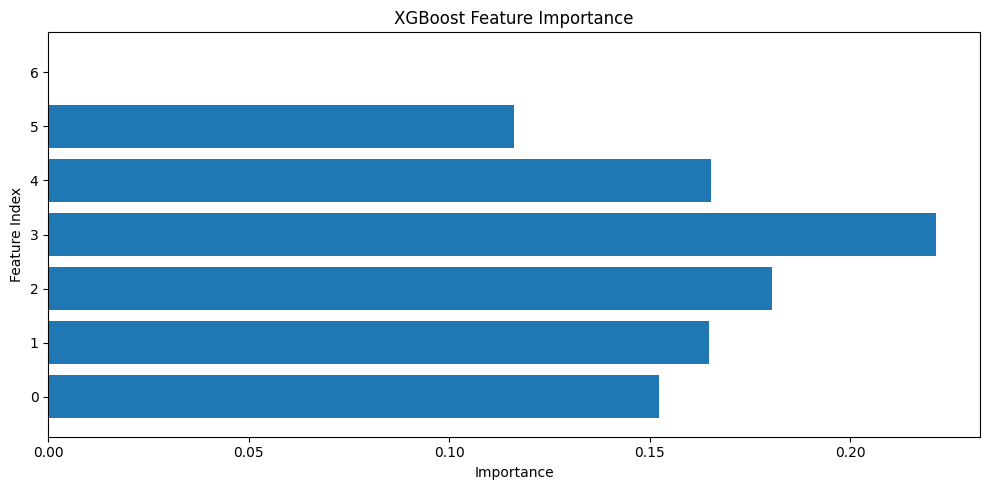

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import time
import numpy as np

# 0. Sample the dataset
sampled_train = train.sample(n=5000, random_state=42)

# 1. Select features and target
X = sampled_train.drop(columns=['Date', 'Ticker', 'Target'])
y = sampled_train['Target']

# 2. Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define XGBoost model
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

# 4. Hyperparameter grid
xgb_param_grid = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 8)
}

# 5. Randomized search for hyperparameter tuning
search = RandomizedSearchCV(
    xgb_model,
    xgb_param_grid,
    n_iter=5,  # Fewer iterations for faster training
    cv=3,
    scoring='accuracy',
    random_state=42
)

start_time = time.time()
search.fit(X_train, y_train)
train_time = time.time() - start_time

# 6. Evaluation
best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=3, scoring='accuracy')

# 7. Results
print("\n=== XGBoost Results on Sampled Data ===")
print(f"Best Params: {search.best_params_}")
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"CV Accuracy: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"Training Time: {train_time:.2f}s")
print(classification_report(y_val, y_pred))

# 8. Feature importance plot
plt.figure(figsize=(10, 5))
importances = best_xgb.feature_importances_
plt.barh(range(len(importances)), importances)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature Index")
plt.tight_layout()
plt.show()
